In [1]:
import os
import torch
from torch import nn
import torch.distributed as dist
from torch.utils.data import WeightedRandomSampler
import torch.optim as optim

import scanpy as sc

import pandas as pd
import numpy as np

from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.model_selection import train_test_split

import anndata as ad
from anndata.experimental import AnnCollection
from anndata.experimental.pytorch import AnnLoader

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using cpu device


In [3]:
labels = ['astro', 'exc1', 'exc2', 'exc3', 'immune', 'inhi', 'oligo', 'opcs', 'vasc']

# inner dict holds the original data, hvg subset, and pseudobatched data
# keeping all of them helps us compare them later to see the effects of pre-processing

datasets = {
    label: {'orig': None, 'subset': None, 'pseudo': None} 
    for label in labels
}

print(list(datasets.keys()))
print(list(datasets.values()))

['astro', 'exc1', 'exc2', 'exc3', 'immune', 'inhi', 'oligo', 'opcs', 'vasc']
[{'orig': None, 'subset': None, 'pseudo': None}, {'orig': None, 'subset': None, 'pseudo': None}, {'orig': None, 'subset': None, 'pseudo': None}, {'orig': None, 'subset': None, 'pseudo': None}, {'orig': None, 'subset': None, 'pseudo': None}, {'orig': None, 'subset': None, 'pseudo': None}, {'orig': None, 'subset': None, 'pseudo': None}, {'orig': None, 'subset': None, 'pseudo': None}, {'orig': None, 'subset': None, 'pseudo': None}]


In [4]:
p = '/data/users/isanor/kand/data/conv_data/'

files = ['Astrocytes.h5ad',
         'Excitatory_neurons_set1.h5ad',
         'Excitatory_neurons_set2.h5ad',
         'Excitatory_neurons_set3.h5ad',   
         'Immune_cells.h5ad',   
         'Inhibitory_neurons.h5ad',   
         'Oligodendrocytes.h5ad',   
         'OPCs.h5ad',
         'Vasculature_cells.h5ad']

def read_files(p, files, to_include):
    for i in to_include:
        l = labels[i]
        print(f'Reading: {l}')
        
        f = os.path.join(p,files[i])
        
        adata = ad.read_h5ad(f)
        datasets[l]['orig'] = adata
       
to_include = list(range(6,len(files)))
to_include = [8]
print(f'Indexes to include: {to_include}')

included_labels = [labels[i] for i in to_include]
print(f'Labels to include: {included_labels}')

read_files(p, files, to_include)

for label in included_labels:
    dataset = datasets.get(label)['orig']
    # need to log normalize, some datasets seem to not be properly normalized in the logcounts layer
    # if we just use the logcounts layer it causes crashes when extracting HVGs

    # TODO try using the log-norm data just for feature selection, give raw counts to pseudobatch
    dataset.uns['log1p'] = sc.pp.log1p(dataset, copy=True)
    print(dataset)


Indexes to include: [8]
Labels to include: ['vasc']
Reading: vasc
AnnData object with n_obs × n_vars = 17974 × 33538
    obs: 'cell_type_high_resolution', 'subject', 'ident'
    uns: 'log1p'
    obsm: 'X_umap'
    layers: 'logcounts'


In [5]:
def plot_distribution(ad, title):
    # Take the first cell and exclude zeros to see the expression curve
    first_cell = ad.X[0, :].copy()
    if hasattr(first_cell, "toarray"): first_cell = first_cell.toarray()

    
    plt.figure(figsize=(8, 4))
    sns.histplot(first_cell, bins=50, kde=True)
    plt.title(f"Non-zero Expression Distribution: {title}")
    plt.xlabel("Value in adata.X")
    plt.show()

#for i, item in enumerate(data):
#    print(labels[i])
#    # use log normalized counts from Mathys et. al
#    plot_distribution(item, labels[i])

In [6]:
print(datasets[included_labels[0]]['orig'].X.min())
print(datasets[included_labels[0]]['orig'].X.max())
print(datasets[included_labels[0]]['orig'].uns['log1p'].X)

0.0
2512.0
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 28258935 stored elements and shape (17974, 33538)>
  Coords	Values
  (0, 20)	0.6931471805599453
  (0, 46)	0.6931471805599453
  (0, 48)	0.6931471805599453
  (0, 76)	0.6931471805599453
  (0, 78)	1.0986122886681098
  (0, 91)	0.6931471805599453
  (0, 151)	0.6931471805599453
  (0, 178)	0.6931471805599453
  (0, 198)	1.0986122886681098
  (0, 214)	0.6931471805599453
  (0, 219)	0.6931471805599453
  (0, 222)	0.6931471805599453
  (0, 226)	0.6931471805599453
  (0, 237)	1.0986122886681098
  (0, 264)	1.0986122886681098
  (0, 277)	0.6931471805599453
  (0, 315)	0.6931471805599453
  (0, 316)	0.6931471805599453
  (0, 346)	0.6931471805599453
  (0, 362)	0.6931471805599453
  (0, 391)	0.6931471805599453
  (0, 439)	0.6931471805599453
  (0, 443)	0.6931471805599453
  (0, 450)	1.0986122886681098
  (0, 451)	1.3862943611198906
  :	:
  (17973, 33154)	0.6931471805599453
  (17973, 33211)	0.6931471805599453
  (17973, 33245)	0.6931471805599453
  

In [7]:
### Keep only highly variable genes (HVGs)

def extract_common_hvgs(to_include, n):
    hvgs = []

    # extract HVGs (NOTE: expects normalized data)
    for label in included_labels:
        print(f'Extracting HVGS from "{label}"')

        # use log1p layer
        adata = datasets[label]['orig'].uns['log1p']

        sc.pp.highly_variable_genes(adata, n_top_genes=2000)
        g = adata.var_names[adata.var.highly_variable]
        hvgs.append(g)

    # find the genes that are HVGs for all datasets
    common_hvgs = set(hvgs[0])
    for i in range(1, len(hvgs)):
        common_hvgs = common_hvgs & set(hvgs[i])
    common_hvgs = list(common_hvgs)

    print(f'Nr common hvgs: {len(common_hvgs)}')

    # keep only HVGs
    for label in included_labels:
        datasets[label]['subset'] = datasets[label]['orig'][:, common_hvgs].copy()
        print(f'HVGs for {label}')
        print(datasets[label]['subset'])

extract_common_hvgs(to_include, 2000)

Extracting HVGS from "vasc"
Nr common hvgs: 2000
HVGs for vasc
AnnData object with n_obs × n_vars = 17974 × 2000
    obs: 'cell_type_high_resolution', 'subject', 'ident'
    uns: 'log1p'
    obsm: 'X_umap'
    layers: 'logcounts'


In [8]:
### Pseudobulk

def do_pseudobulk(adata):
    pseudo = sc.get.aggregate(
    adata, 
    by=['subject', 'cell_type_high_resolution'], 
    func='sum'
    )

    # moves pseudobulk to the main layer
    pseudo.X = pseudo.layers['sum'].copy()

    return pseudo

for label in included_labels:
    print(f'Pseudobulking "{label}"')
    pseudo = do_pseudobulk(datasets[label]['subset'])
    datasets[label]['pseudo'] = pseudo
    print(pseudo)

Pseudobulking "vasc"
AnnData object with n_obs × n_vars = 1595 × 2000
    obs: 'subject', 'cell_type_high_resolution', 'n_obs_aggregated'
    layers: 'sum'


In [9]:
def normalize(adata):
    # Normalizes counts per pseudobulk sample
    # There are possible options, e.g. exclude highly expressed genes from computation

    # Using Counts per million
    sc.pp.normalize_total(adata, exclude_highly_expressed=False, target_sum=1e6)

    # Especially useful if range is large?
    sc.pp.log1p(adata)

    # Scaling centers genes at 0
    # Helps model learn *relative* expression
    sc.pp.scale(adata)

for label in included_labels:
    print(f'Normalizing: "{label}"')
    normalize(datasets[label]['pseudo'])
    
    print(datasets[label]['pseudo'])

Normalizing: "vasc"
AnnData object with n_obs × n_vars = 1595 × 2000
    obs: 'subject', 'cell_type_high_resolution', 'n_obs_aggregated'
    var: 'mean', 'std'
    uns: 'log1p'
    layers: 'sum'


In [10]:
for label in included_labels:
    dataset = datasets[label]['pseudo']
    print(f'{label:<8} has min: {dataset.X.min():.2f} and max: {dataset.X.max():.2f}')

vasc     has min: -2.84 and max: 39.91


In [11]:
datasets[included_labels[0]]['orig'].obs['cell_type_high_resolution']

GACTACAAGGCTCTTA-1-0      Fib SLC4A4
ACTGAGTTCACTTATC-2-0       Fib FLRT2
CACAAACGTAAGGGAA-2-0       Fib FLRT2
CGGTTAAAGGCTCAGA-2-0       Fib FLRT2
TACCTTACATTAACCG-2-0       Fib FLRT2
                             ...    
CATTCCGAGCGACCCT-16-14           Per
CGAAGGACAACGAGGT-16-14           Per
CTAGACAAGCCACCGT-16-14           End
TTACGTTAGTAAACAC-16-14           End
TTTCGATTCGGTTCAA-16-14           Per
Name: cell_type_high_resolution, Length: 17974, dtype: category
Categories (5, object): ['End', 'Fib FLRT2', 'Fib SLC4A4', 'Per', 'SMC']

In [12]:
### GET METADATA

p = '/data/users/isanor/kand/data/supplementary_data/'
f = 'individual_metadata_deidentified.tsv'
print(os.path.exists(p+f))
metadata = pd.read_csv(p+f,sep='\t')

AD_status_lbl = 'Pathologic_diagnosis_of_AD'
md_sel = metadata[['subject', AD_status_lbl]]

# Annotate the data with the disease status of the subject

# floats for logits loss
# int for BCE loss
md_sel[AD_status_lbl].replace(to_replace='yes', value=1.0, inplace=True)
md_sel[AD_status_lbl].replace(to_replace='no', value=0.0, inplace=True)

print(md_sel)

# create map with subject as key, AD status as value
status_map = dict(zip(md_sel['subject'], md_sel[AD_status_lbl]))

for label in included_labels:
    pseudo = datasets[label]['pseudo']

    subjects = pseudo.obs['subject'].astype(str).values

    new_statuses = [str(status_map.get(s)) for s in subjects]
    
    pseudo.obs['AD_status'] = new_statuses
    
    pseudo.obs['AD_status'] = pseudo.obs['AD_status'].astype('category')

    print(pseudo)

True
          subject  Pathologic_diagnosis_of_AD
0    ROSMAP-10132                         1.0
1    ROSMAP-10643                         1.0
2    ROSMAP-10859                         1.0
3    ROSMAP-12078                         1.0
4    ROSMAP-12256                         1.0
..            ...                         ...
422  ROSMAP-98582                         0.0
423  ROSMAP-98683                         1.0
424  ROSMAP-99419                         0.0
425  ROSMAP-99585                         1.0
426  ROSMAP-99981                         1.0

[427 rows x 2 columns]
AnnData object with n_obs × n_vars = 1595 × 2000
    obs: 'subject', 'cell_type_high_resolution', 'n_obs_aggregated', 'AD_status'
    var: 'mean', 'std'
    uns: 'log1p'
    layers: 'sum'


/tmp/ipykernel_3077115/3469568409.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  md_sel[AD_status_lbl].replace(to_replace='yes', value=1.0, inplace=True)
/tmp/ipykernel_3077115/3469568409.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  md_sel[AD_status_lbl].replace(to_replace='yes', value=1.0, inplace=True)
/tmp/ipykernel_3077115/34

Drawing umaps for vasc


/tmp/ipykernel_3077115/354495169.py:21: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.umap(adata_proc, title=f"{label} pre-processed", color=['cell_type_high_resolution'], save=fname2)


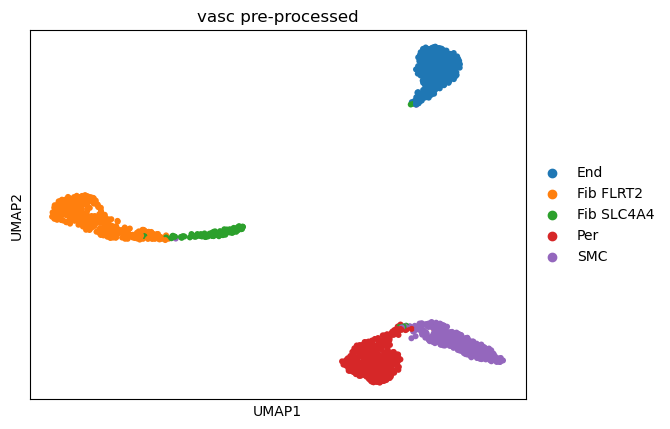

In [ ]:
def draw_umaps(adata, adata_proc, label):
    p = '/data/users/isanor/kand/proj/BBTX11-VT26-07/figures/'
    fname1 = label + '_orig'
    fname1 = os.path.join(p,fname1)
    fname2 = label + '_proc'
    fname1 = os.path.join(p,fname2)

    # UMAP for original
    sc.tl.pca(adata, svd_solver='arpack')
    sc.pp.neighbors(adata, n_neighbors=20, n_pcs = 30)
    sc.tl.umap(adata)
    sc.pl.umap(adata, title=f"{label} original", color=['cell_type_high_resolution'], save=fname1)
    sc.pl.plot(show=False).figure.savefig()

    # UMAP for preprocessed
    sc.tl.pca(adata_proc, svd_solver='arpack')
    sc.pp.neighbors(adata_proc, n_neighbors=20, n_pcs = 30)
    sc.tl.umap(adata_proc)
    sc.pl.umap(adata_proc, title=f"{label} pre-processed", color=['cell_type_high_resolution'], save=fname2)

for label in included_labels:
    dataset = datasets[label]
    print(f'Drawing umaps for {label}')
    draw_umaps(dataset['orig'], dataset['pseudo'], label)


In [17]:
p = '/data/users/isanor/kand/proj/BBTX11-VT26-07/figures'
os.path.exists(p)

True

In [ ]:
### Encoding

# Encoding by general cell type
cell_type_low_res_encoder = OneHotEncoder(sparse_output=False, dtype=np.float32)

# Encoding by fine-grained cell type
cell_type_high_res_encoder = OneHotEncoder(sparse_output=False, dtype=np.float32)

# Encode disease status
status_encoder = LabelEncoder()

converters = {
    'obs': {
        # One-hot encode the covariates
        'cell_type_low_res': lambda x: cell_type_low_res_encoder.transform(x.to_numpy()[:, None]),
        'cell_type_high_res': lambda x: cell_type_high_res_encoder.transform(x.to_numpy()[:, None]),
        
        # Label encode the target (AD_status)
        'AD_status': status_encoder.transform
    }
}

In [ ]:
for i in to_include:
    included_pseudo = [datasets[labels[i]]['pseudo'] for i in to_include]

In [ ]:
# We can join several data sets together in a collection

# labels as keys, adata objects as values, e.g.
# {'immune': adata_obj, 'oligo': adata_obj}

collection_contents = dict(zip(included_labels, included_pseudo))

# This is the way to do it with a large dataset
collection = AnnCollection(
    collection_contents,
    join_vars='outer', # keep all records
    label='cell_type_low_res',
    convert=converters, # do encoding when creating the collection
    indices_strict=False # in case there exist cells with same ID (unlikely here?)
)

# for brevity
collection.obs.rename(columns={'cell_type_high_resolution': 'cell_type_high_res'}, inplace=True)

print(collection)

print(collection.obs['AD_status'].head())

In [ ]:
### Fit encodings

cell_type_low_res_encoder.fit(collection.obs["cell_type_low_res"].to_numpy()[:,None])

cell_type_high_res_encoder.fit(collection.obs["cell_type_high_res"].to_numpy()[:,None])

status_encoder.fit(collection.obs["AD_status"])

In [ ]:
### Train test split

indices = np.arange(collection.n_obs)

train_size = 0.8
train_idx, test_idx = train_test_split(
    indices,
    test_size=1-train_size,
    stratify=collection.obs['cell_type_high_res'],
    random_state = 34
)

train_obs = collection.obs.iloc[train_idx]
train_cell_types = train_obs['cell_type_high_res'].values
train_type_counts = pd.Series(train_cell_types).value_counts()

from sklearn.model_selection import GroupShuffleSplit

# Create a unique ID for each subject (not row)
# We also need their disease status for stratification
subject_metadata = collection.obs[['subject', 'AD_status']].drop_duplicates()

# This ensures that all rows with the same 'subject' stay together
gss = GroupShuffleSplit(n_splits=1, train_size=0.8, random_state=34)

# Perform the split
# We pass the 'AD_status' to the groups context to maintain balance
train_idx, test_idx = next(gss.split(
    X=collection.obs, 
    y=collection.obs['AD_status'], 
    groups=collection.obs['subject']
))

# Create training and testing objects
train_adata = collection[train_idx]
test_adata = collection[test_idx]

# Verify the results
print(f"Train Subjects: {train_adata.obs['subject'].nunique()}")
print(f"Test Subjects: {test_adata.obs['subject'].nunique()}")


In [ ]:
### Loaders 

train_loader = AnnLoader(train_adata, batch_size=128, shuffle=False)
test_loader = AnnLoader(test_adata, batch_size=128, shuffle=False)

batch = next(iter(train_loader))


In [ ]:
class AD_classifier(nn.Module):
    def __init__(self, input_dim):
        super(AD_classifier, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Linear(128, 1), # Single output for binary classification
        )
    
    def forward(self, x):
        return self.network(x)

In [ ]:
model = AD_classifier(input_dim=collection.n_vars)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

In [ ]:
import warnings
warnings.filterwarnings('ignore')

epochs = 25
for epoch in range(epochs):
    model.train()
    train_loss = 0.0

    # training loop
    for batch in train_loader:
        # Extracting gene expression and AD status
        X_batch = torch.tensor(batch.X, dtype=torch.float32).to(device)
        y_batch = batch.obs['AD_status'].float().to(device)
        
        # forward pass
        outputs = model(X_batch).squeeze()
        loss = criterion(outputs, y_batch.float())

        # backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    # validation loop
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for batch_val in test_loader:
            # Unpacking the data
            X_val = torch.tensor(batch_val.X, dtype=torch.float32).to(device)
            y_val = batch_val.obs['AD_status'].float().to(device)
            
            # make prediction
            outputs = model(X_val).squeeze()
            loss = criterion(outputs, y_val.float())
            val_loss += loss.item()

            predicted = (outputs > 0.5).float()
            total += y_val.size(0)
            correct += (predicted == y_val).sum().item()

    avg_train = train_loss / len(train_loader)
    avg_val = val_loss / len(test_loader)
    accuracy = 100 * correct / total

    print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {avg_train:.4f} | Val Loss: {avg_val:.4f} | Val Acc: {accuracy:.2f}%")












